<a href="https://colab.research.google.com/github/DanLincoln24/FrameworksLaba1/blob/main/%D0%9B%D0%B0%D0%B1%D0%B0%E2%84%961%D0%A4%D1%80%D0%B5%D0%B9%D0%BC%D0%B2%D0%BE%D1%80%D0%BA%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №1 по Фреймворкам Python для анализа данных
# Гаврилов Данила 103

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
from sklearn.preprocessing import StandardScaler

In [3]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


# Часть 1: EDA
## Проведём разведочный анализ данных

### 1) Проверка типов данных

In [4]:
df = pd.read_csv('/content/drive/MyDrive/student_lifestyle_100k.csv', sep = ",")
df.head()

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  object 
 3   Department          100000 non-null  object 
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), object(2)
memory usage: 7.7+ MB


#### Имеем 11 колонок по 100_000 строк каждая
##### 4 колонки типа int, 4 float, 1 bool и две текстовых






### 2) Анализ целевой переменной
#### Предсказываем CGPA - средний балл студента; Уровень успеваемости
##### Вещественное число от 0 до 4

#### Посмотрим распределение значений целевой переменной





/tmp/ipykernel_19346/1308175046.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='CGPA',


<Axes: ylabel='CGPA'>

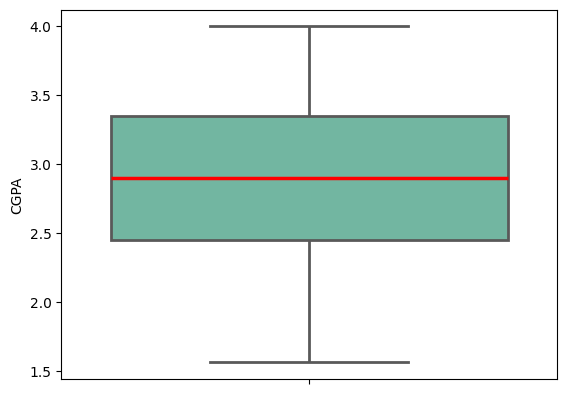

In [6]:
sns.boxplot(data=df, y='CGPA',
            palette='Set2', linewidth=2,
            medianprops=dict(color='red', linewidth=2.5))


### 3) Анализ признаков

Удалим дубликаты:

In [7]:
df_no_dubl = df[df.duplicated()]
print("Число дублей: ", df_no_dubl.shape)
df = df.drop_duplicates()

Число дублей:  (0, 11)


Посмотрим пропуски:

In [8]:
print(df.isna().sum())

Student_ID            0
Age                   0
Gender                0
Department            0
CGPA                  0
Sleep_Duration        0
Study_Hours           0
Social_Media_Hours    0
Physical_Activity     0
Stress_Level          0
Depression            0
dtype: int64


####ID студента не несёт никакой ценности для модели
#### Удаляем ненужный признак:

In [9]:
df.drop(columns=['Student_ID'], inplace=True)

In [11]:
df.head()

,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


####Посмотрим на выбросы и построим ещё графики

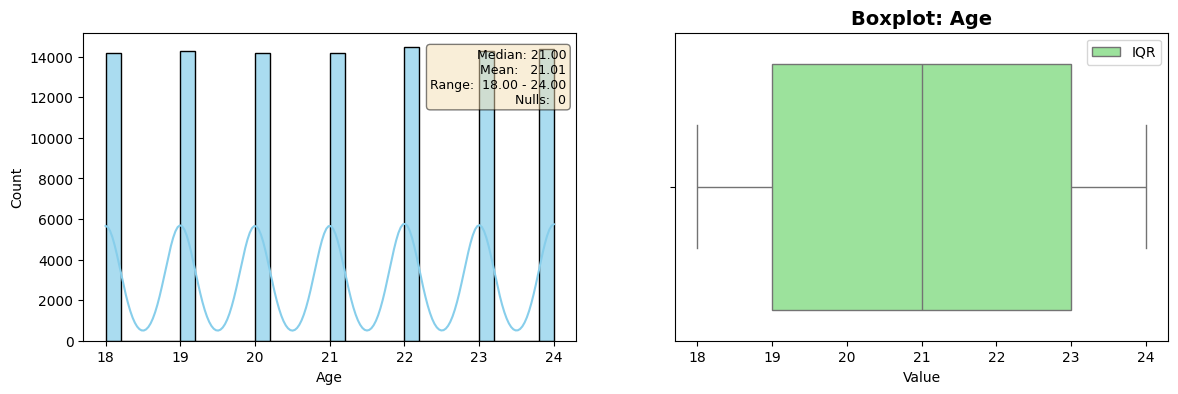

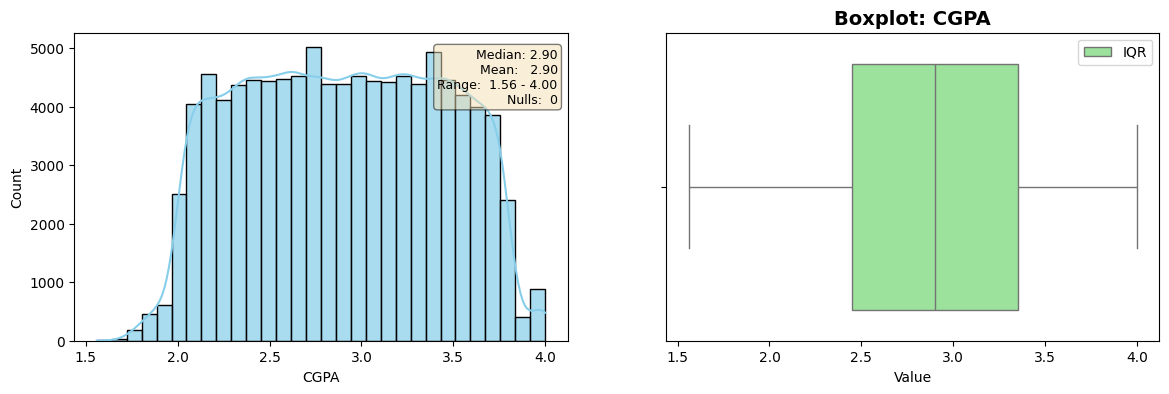

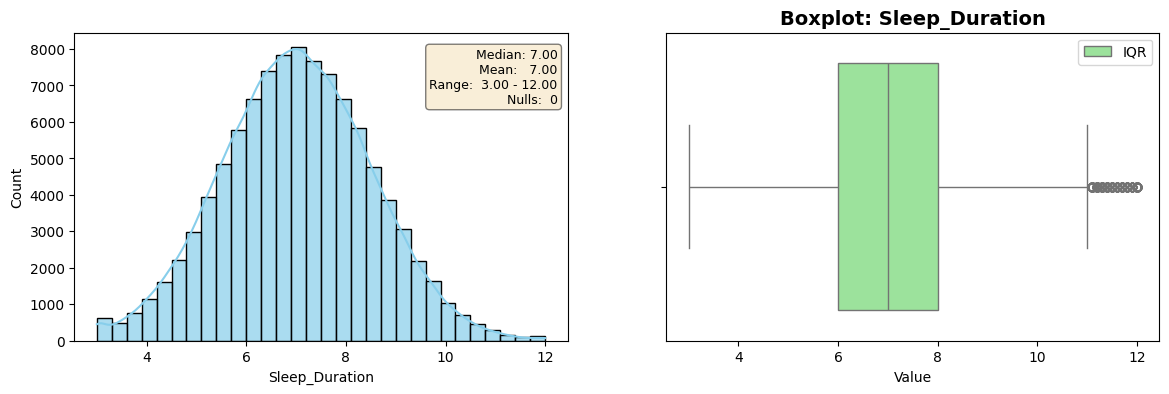

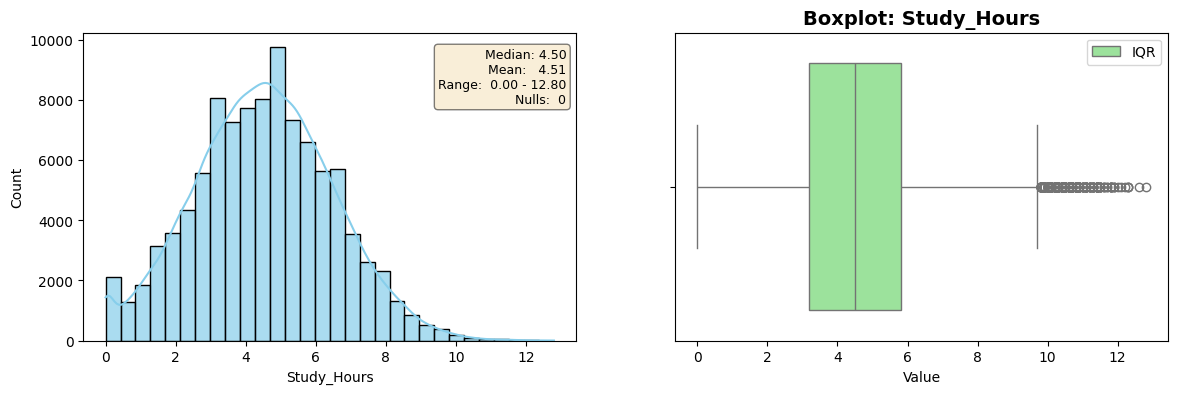

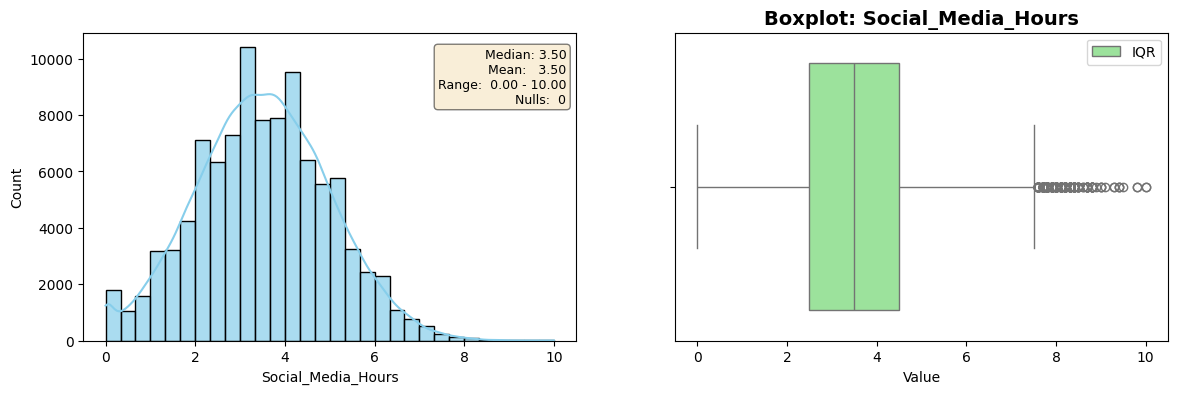

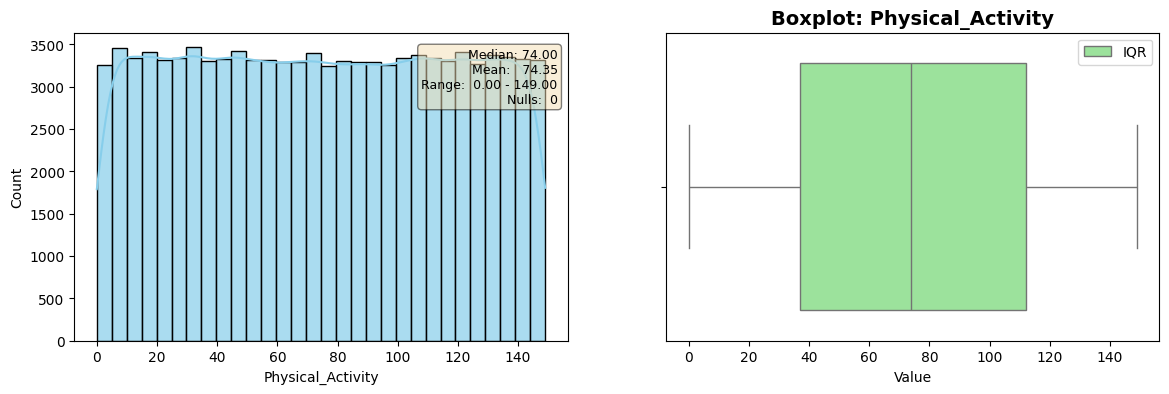

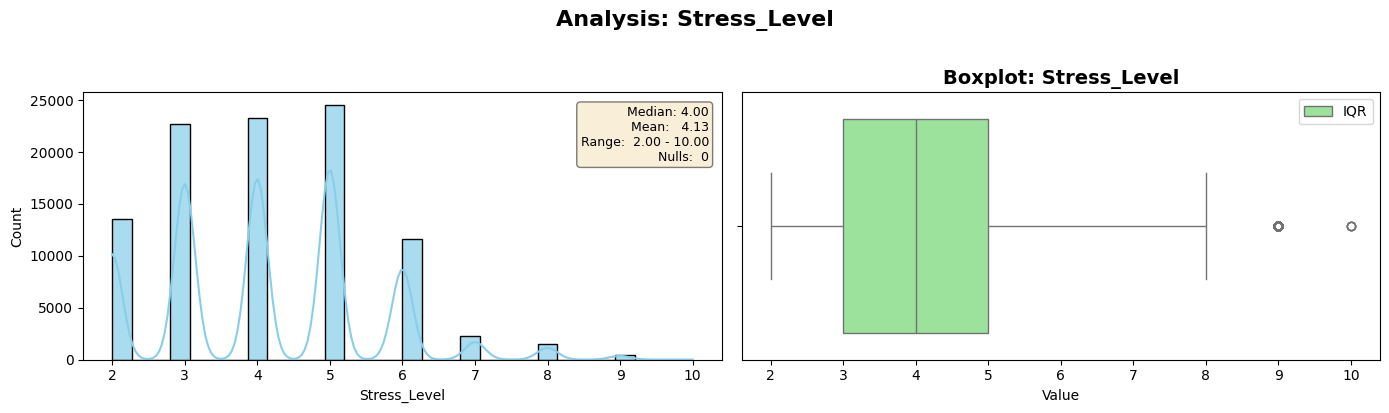

[OK] Stress_Level:
   |- Distribution: symmetric
   |- Missing values: 0
   |- Outliers (IQR): 478
--------------------------------------------------------------------------------


In [12]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
for col in numeric_cols:
  fig, axes = plt.subplots(1, 2, figsize=(14, 4))
  sns.histplot(data=df, x=col, bins=30, kde=True, ax=axes[0],
                     color='skyblue', edgecolor='black', alpha=0.7)

  sns.boxplot(data=df, x=col, ax=axes[1], color='lightgreen')
  axes[1].set_title(f'Boxplot: {col}', fontsize=14, fontweight='bold')
  axes[1].set_xlabel('Value')
  axes[1].legend(['IQR', 'Median', 'Outliers'], loc='best')

  stats_text = (f"Median: {df[col].median():.2f}\n"
                     f"Mean:   {df[col].mean():.2f}\n"
                     f"Range:  {df[col].min():.2f} - {df[col].max():.2f}\n"
                     f"Nulls:  {df[col].isnull().sum()}")

  axes[0].text(0.98, 0.95, stats_text, transform=axes[0].transAxes,
                     fontsize=9, verticalalignment='top', horizontalalignment='right',
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle(f'Analysis: {col}', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

col_data = df[col].dropna()

if len(col_data) > 0:
    Q1 = col_data.quantile(0.25)
    Q3 = col_data.quantile(0.75)
    IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_count = ((col_data < lower_bound) | (col_data > upper_bound)).sum()
missing_count = df[col].isnull().sum()

skew = col_data.skew()
if abs(skew) < 0.5:
    skew_text = "symmetric"
elif skew > 0:
    skew_text = "right-skewed"
else:
    skew_text = "left-skewed"

print(f"[OK] {col}:")
print(f"   |- Distribution: {skew_text}")
print(f"   |- Missing values: {missing_count}")
print(f"   |- Outliers (IQR): {outliers_count}")
print("-" * 80)


Наблюдаем нормальное распределение у таргета, а также у признаков "study_hours", "social_media_hours" и "sleep_duration"

Равноерное распределение видим у ages и physical_activity

# Часть 2: Feature engineering
### Кодируем категориальные признаки

In [13]:
df = pd.get_dummies(df, columns=['Department', 'Gender'],
                       prefix=['Department', 'Gender'], drop_first=True)
print(df)

       Age  CGPA  Sleep_Duration  Study_Hours  Social_Media_Hours  \
0       22  3.50             7.3          3.3                 3.4   
1       20  2.72             5.5          7.2                 6.0   
2       20  3.01             5.4          2.3                 1.8   
3       21  3.63             8.1          2.0                 4.6   
4       19  3.14             6.8          2.6                 4.3   
...    ...   ...             ...          ...                 ...   
99995   24  2.02             7.0          0.6                 1.4   
99996   24  2.33             5.0          3.6                 5.2   
99997   24  2.23             6.5          5.8                 4.1   
99998   19  3.61             6.1          4.8                 4.9   
99999   24  2.10             7.9          3.5                 4.0   

       Physical_Activity  Stress_Level  Depression  Department_Business  \
0                    114             5       False                False   
1                    

In [14]:
!pip install feature_engine
from feature_engine.outliers import Winsorizer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 8.3 MB/s eta 0:00:00


#### Заменили все выбросы у числовых признаков, а именно значения которые меньше 5% данных и выше 95% данных на 5-ый и 95-ый перцентиль соответственно

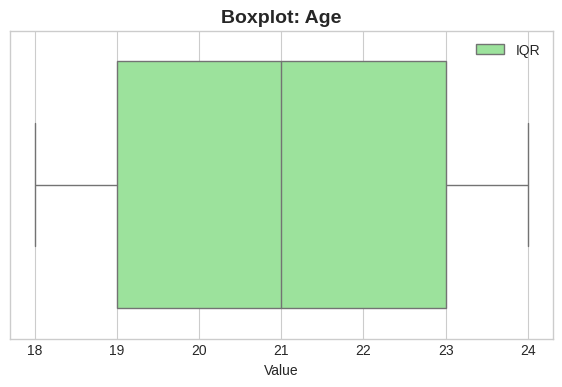

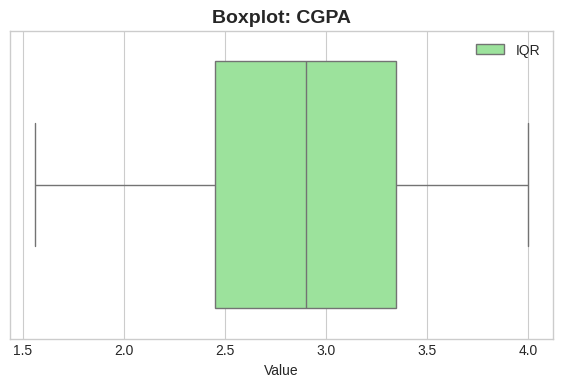

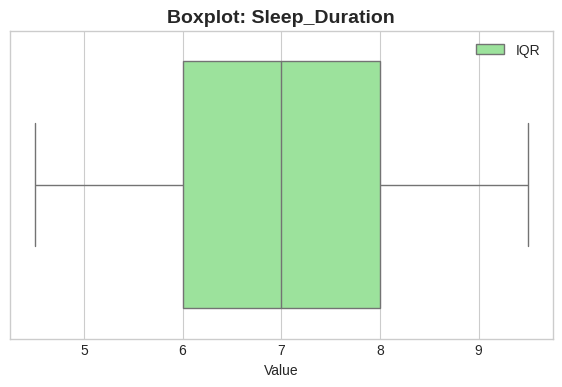

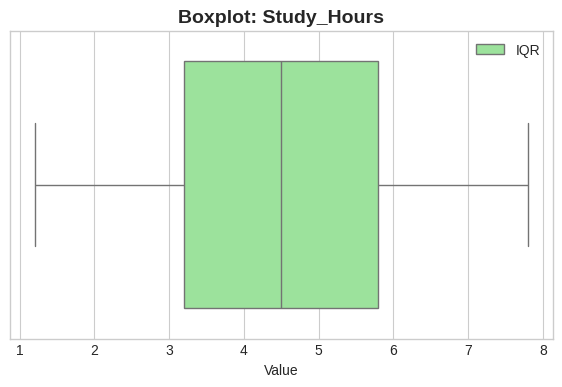

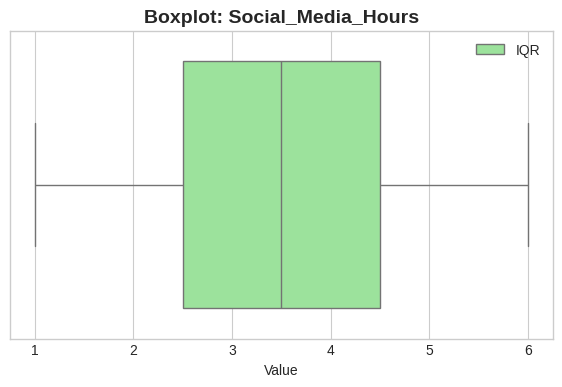

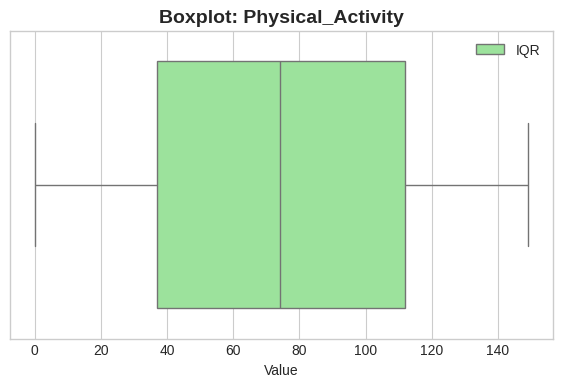

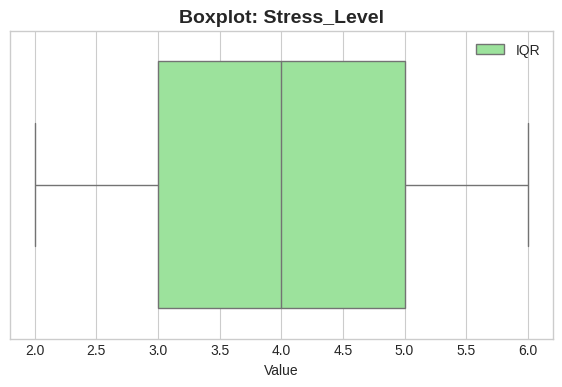

In [27]:
winsorizer = Winsorizer(capping_method='quantiles',
                        tail='both', fold=0.05, variables=['Stress_Level', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours'])
df = winsorizer.fit_transform(df)

for col in numeric_cols:
    fig, ax = plt.subplots(1, 1, figsize=(7, 4))

    sns.boxplot(data=df, x=col, ax=ax, color='lightgreen')
    ax.set_title(f'Boxplot: {col}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Value')
    ax.legend(['IQR', 'Median', 'Outliers'], loc='best')


#### Обработали выбросы, переходим к обучению модели

# Часть 3: Линейная регрессия
### Задача: педсказания среднего балла успеваемости студента (CGPA)

### Проанализируем графики распределения целевой переменной у категориальных признаков (Department и Gender)

/tmp/ipykernel_19346/3986308995.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=categories, patch_artist=True,
/tmp/ipykernel_19346/3986308995.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=categories, patch_artist=True,


{'whiskers': [<matplotlib.lines.Line2D at 0x7820383bdd90>,
 'caps': [<matplotlib.lines.Line2D at 0x7820383be390>,
 'boxes': [<matplotlib.patches.PathPatch at 0x7820383bda90>,
 'medians': [<matplotlib.lines.Line2D at 0x7820383bea20>,
 'fliers': [<matplotlib.lines.Line2D at 0x7820383bed50>,
 'means': []}

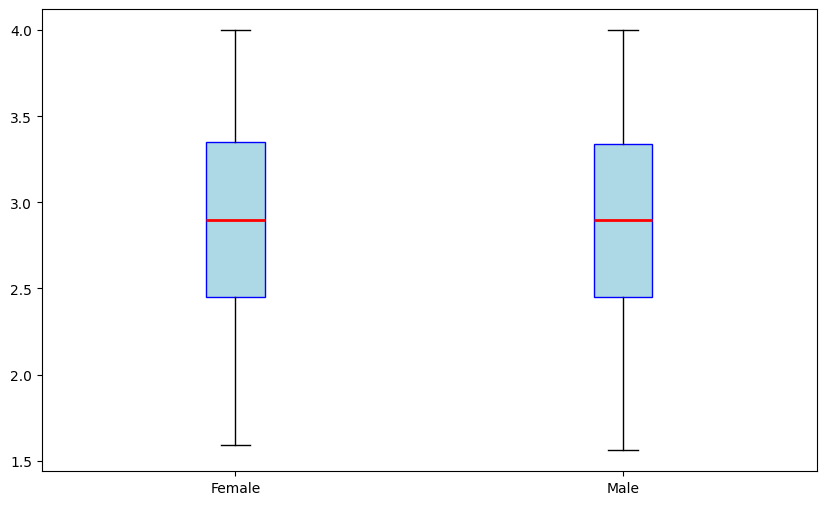

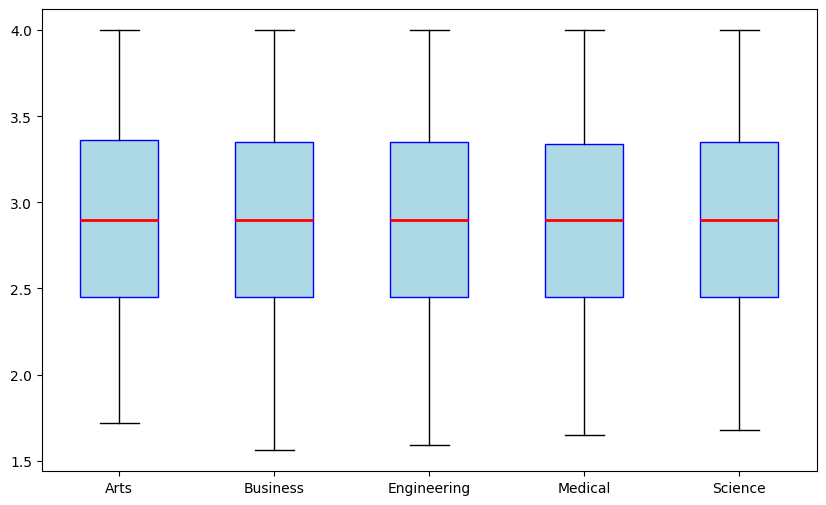

In [10]:
data = df.groupby('Gender')['CGPA'].apply(list).to_dict()
categories = list(data.keys())
values = [data[cat] for cat in categories]

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(values, labels=categories, patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='blue'),
           medianprops=dict(color='red', linewidth=2))

data = df.groupby('Department')['CGPA'].apply(list).to_dict()
categories = list(data.keys())
values = [data[cat] for cat in categories]

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(values, labels=categories, patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='blue'),
           medianprops=dict(color='red', linewidth=2))

#### У распределения всех категорий нет различий
#### Корелляция близка к нулевой, значит эти признаки тоже можем не учитывать


In [16]:
df_linr = df.drop(columns=['Gender_Male','Department_Engineering', 'Department_Business', 'Department_Medical', 'Department_Science'])
print(df_linr)

       Age  CGPA  Sleep_Duration  Study_Hours  Social_Media_Hours  \
0       22  3.50             7.3          3.3                 3.4   
1       20  2.72             5.5          7.2                 6.0   
2       20  3.01             5.4          2.3                 1.8   
3       21  3.63             8.1          2.0                 4.6   
4       19  3.14             6.8          2.6                 4.3   
...    ...   ...             ...          ...                 ...   
99995   24  2.02             7.0          1.2                 1.4   
99996   24  2.33             5.0          3.6                 5.2   
99997   24  2.23             6.5          5.8                 4.1   
99998   19  3.61             6.1          4.8                 4.9   
99999   24  2.10             7.9          3.5                 4.0   

       Physical_Activity  Stress_Level  Depression  
0                    114             5       False  
1                    142             2       False  
2           

#### Посмотрим на то же самое распределение для возраста студентов

/tmp/ipykernel_19346/2756262763.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=categories, patch_artist=True,


{'whiskers': [<matplotlib.lines.Line2D at 0x78202f4380e0>,
 'caps': [<matplotlib.lines.Line2D at 0x782039c5c230>,
 'boxes': [<matplotlib.patches.PathPatch at 0x782039c5cb30>,
 'medians': [<matplotlib.lines.Line2D at 0x782039c5da00>,
 'fliers': [<matplotlib.lines.Line2D at 0x782039c5dd00>,
 'means': []}

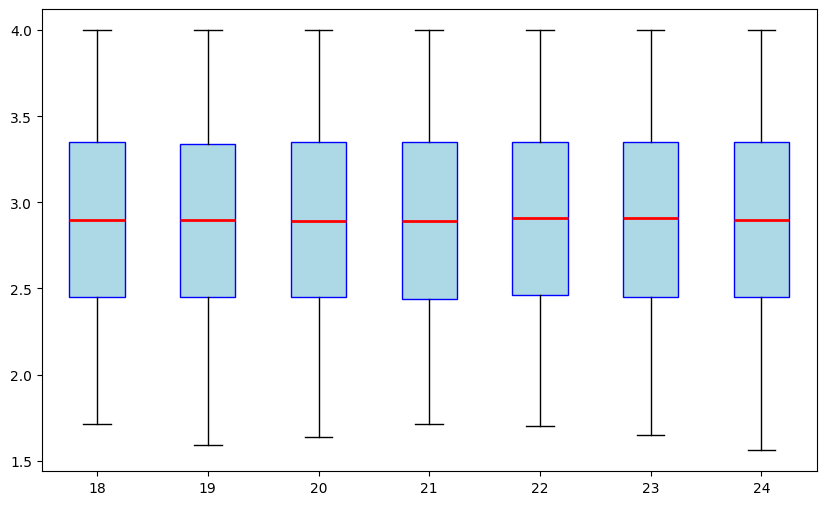

In [17]:
data = df.groupby('Age')['CGPA'].apply(list).to_dict()
categories = list(data.keys())
values = [data[cat] for cat in categories]

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(values, labels=categories, patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='blue'),
           medianprops=dict(color='red', linewidth=2))

### Распределение по целевой переменной в зависимости от возраста также никак не отличается
### Значит этот признак для линейной регрессии тоже учитывать не будем


In [18]:
df_linr = df_linr.drop(columns=['Age'])
print(df_linr)

       CGPA  Sleep_Duration  Study_Hours  Social_Media_Hours  \
0      3.50             7.3          3.3                 3.4   
1      2.72             5.5          7.2                 6.0   
2      3.01             5.4          2.3                 1.8   
3      3.63             8.1          2.0                 4.6   
4      3.14             6.8          2.6                 4.3   
...     ...             ...          ...                 ...   
99995  2.02             7.0          1.2                 1.4   
99996  2.33             5.0          3.6                 5.2   
99997  2.23             6.5          5.8                 4.1   
99998  3.61             6.1          4.8                 4.9   
99999  2.10             7.9          3.5                 4.0   

       Physical_Activity  Stress_Level  Depression  
0                    114             5       False  
1                    142             2       False  
2                    137             3       False  
3                  

## Разделим датасет на обучающую, валидационную и тестовую выборки
### 70% learn, 10% valid, 20% train

## Выполняем линейную регрессию

In [19]:
print(df_linr)

       CGPA  Sleep_Duration  Study_Hours  Social_Media_Hours  \
0      3.50             7.3          3.3                 3.4   
1      2.72             5.5          7.2                 6.0   
2      3.01             5.4          2.3                 1.8   
3      3.63             8.1          2.0                 4.6   
4      3.14             6.8          2.6                 4.3   
...     ...             ...          ...                 ...   
99995  2.02             7.0          1.2                 1.4   
99996  2.33             5.0          3.6                 5.2   
99997  2.23             6.5          5.8                 4.1   
99998  3.61             6.1          4.8                 4.9   
99999  2.10             7.9          3.5                 4.0   

       Physical_Activity  Stress_Level  Depression  
0                    114             5       False  
1                    142             2       False  
2                    137             3       False  
3                  

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

y = df_linr['CGPA']
X = df_linr.drop(columns=['CGPA'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42, shuffle=True)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.125, random_state=42, shuffle=True) # 0.125 x 0.8 = 0.1

model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)


  Выборка: Train
  MAE:  0.44
  RMSE: 0.52
  R²:   0.0503
  MAPE: 16.12%

  Выборка: Test
  MAE:  0.45
  RMSE: 0.52
  R²:   0.0458
  MAPE: 16.15%


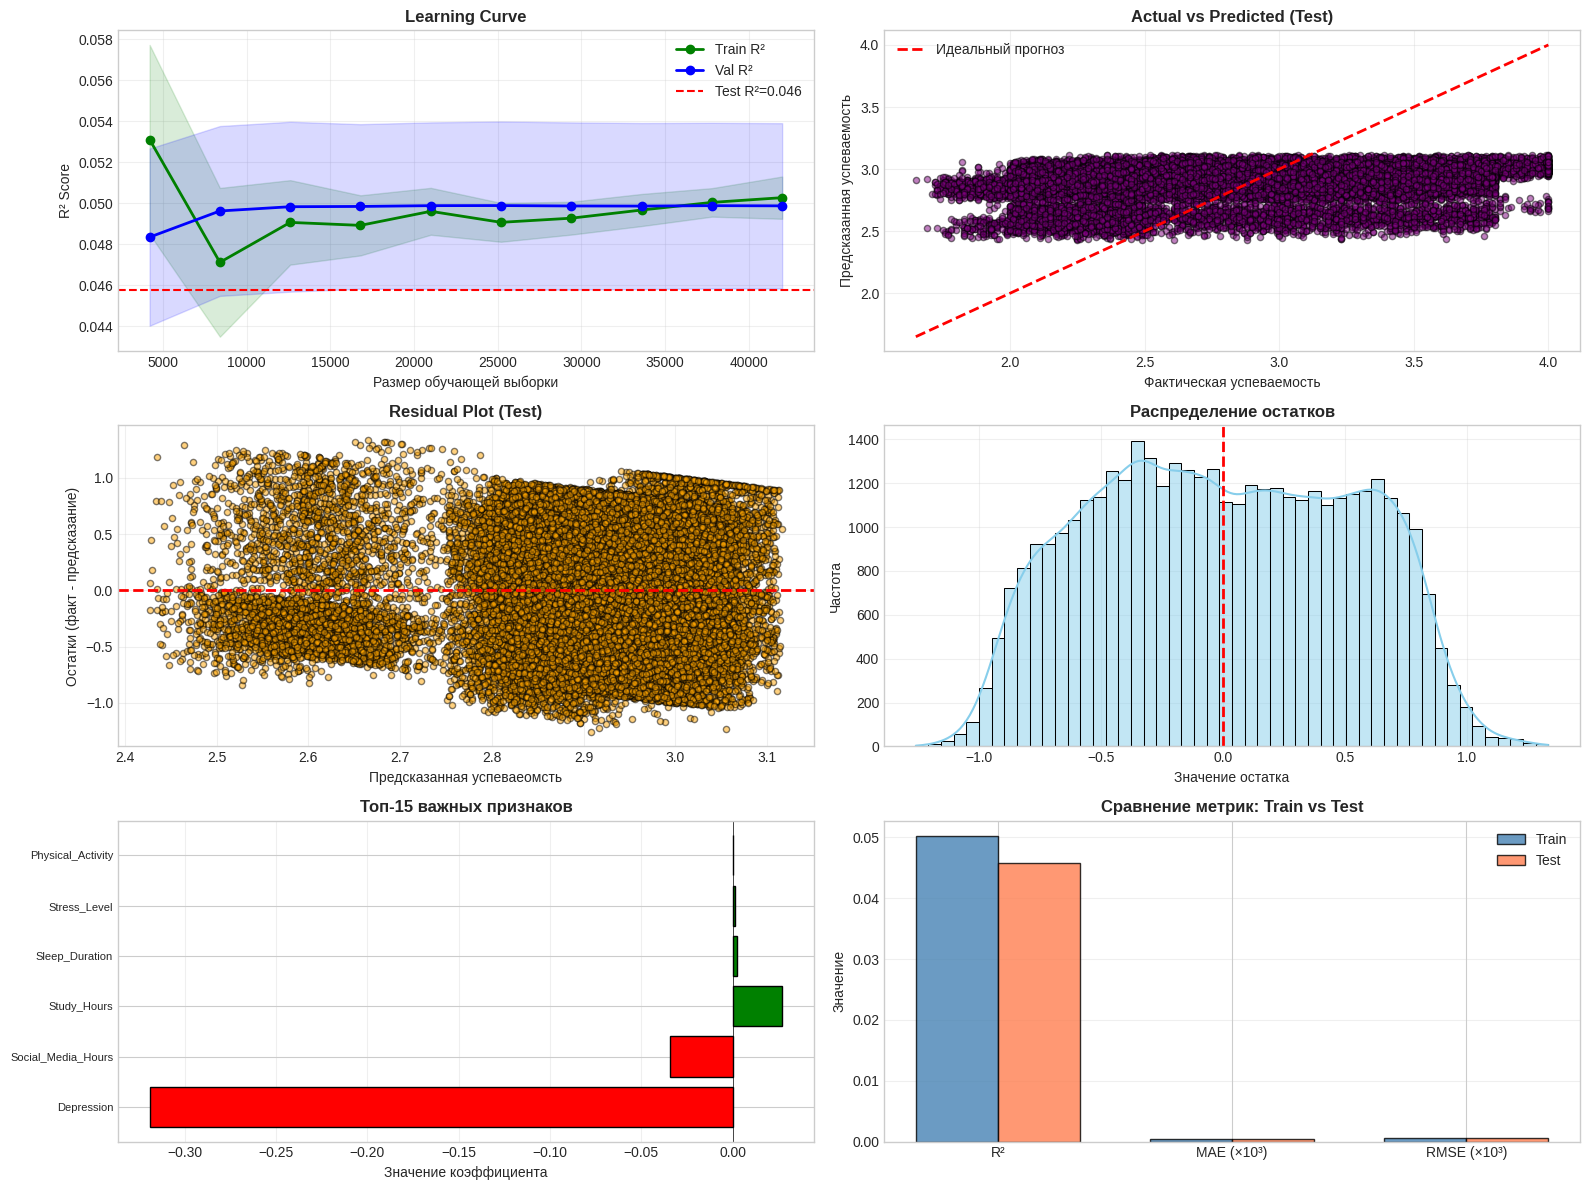

In [21]:
def evaluate_model(y_true, y_pred, dataset_name="Dataset"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    print(f"\n  Выборка: {dataset_name}")
    print(f"  MAE:  {mae:,.2f}")
    print(f"  RMSE: {rmse:,.2f}")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")

    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

train_metrics = evaluate_model(y_train, y_train_pred, "Train")
test_metrics = evaluate_model(y_test, y_test_pred, "Test")
from sklearn.model_selection import learning_curve

plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(16, 12))

ax1 = plt.subplot(3, 2, 1)
train_sizes, train_scores, val_scores = learning_curve(
    model, X_train, y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='r2',
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

ax1.plot(train_sizes, train_mean, 'o-', color='green', label='Train R²', linewidth=2)
ax1.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='green')
ax1.plot(train_sizes, val_mean, 'o-', color='blue', label='Val R²', linewidth=2)
ax1.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='blue')
ax1.set_xlabel('Размер обучающей выборки', fontsize=10)
ax1.set_ylabel('R² Score', fontsize=10)
ax1.set_title('Learning Curve', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=test_metrics['R2'], color='red', linestyle='--', lw=1.5, label=f'Test R²={test_metrics["R2"]:.3f}')
ax1.legend()

ax2 = plt.subplot(3, 2, 2)
ax2.scatter(y_test, y_test_pred, alpha=0.5, edgecolors='black', s=20, color='purple')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальный прогноз')
ax2.set_xlabel('Фактическая успеваемость', fontsize=10)
ax2.set_ylabel('Предсказанная успеваемость', fontsize=10)
ax2.set_title('Actual vs Predicted (Test)', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)


ax3 = plt.subplot(3, 2, 3)
residuals = y_test - y_test_pred
ax3.scatter(y_test_pred, residuals, alpha=0.5, edgecolors='black', s=20, color='orange')
ax3.axhline(y=0, color='red', linestyle='--', lw=2)
ax3.set_xlabel('Предсказанная успеваеомсть', fontsize=10)
ax3.set_ylabel('Остатки (факт - предсказание)', fontsize=10)
ax3.set_title('Residual Plot (Test)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)



ax4 = plt.subplot(3, 2, 4)
sns.histplot(residuals, bins=50, kde=True, ax=ax4, color='skyblue', edgecolor='black')
ax4.axvline(x=0, color='red', linestyle='--', lw=2)
ax4.set_xlabel('Значение остатка', fontsize=10)
ax4.set_ylabel('Частота', fontsize=10)
ax4.set_title('Распределение остатков', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)



ax5 = plt.subplot(3, 2, 5)
coefficients = pd.DataFrame({
    'feature': X.columns,
    'coef': model.coef_
})
coefficients = coefficients.sort_values(by='coef', key=lambda x: np.abs(x), ascending=False).head(15)

colors = ['green' if c > 0 else 'red' for c in coefficients['coef']]
bars = ax5.barh(coefficients['feature'], coefficients['coef'], color=colors, edgecolor='black')
ax5.set_xlabel('Значение коэффициента', fontsize=10)
ax5.set_title('Топ-15 важных признаков', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='x')
ax5.axvline(x=0, color='black', lw=0.5)
plt.setp(ax5.get_yticklabels(), fontsize=8)

ax6 = plt.subplot(3, 2, 6)
metrics_names = ['R²', 'MAE', 'RMSE']
x_pos = np.arange(len(metrics_names))
width = 0.35

train_vals = [train_metrics['R2'], train_metrics['MAE']/1000, train_metrics['RMSE']/1000]
test_vals = [test_metrics['R2'], test_metrics['MAE']/1000, test_metrics['RMSE']/1000]

ax6.bar(x_pos - width/2, train_vals, width, label='Train', alpha=0.8, edgecolor='black', color='steelblue')
ax6.bar(x_pos + width/2, test_vals, width, label='Test', alpha=0.8, edgecolor='black', color='coral')
ax6.set_xticks(x_pos)
ax6.set_xticklabels(['R^2', 'MAE (*10^3)', 'RMSE (*10^3)'])
ax6.set_ylabel('Значение', fontsize=10)
ax6.set_title('Сравнение метрик: Train vs Test', fontsize=12, fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('linear_regression_results.png', dpi=300, bbox_inches='tight')
plt.show()

### Попробуем обучить модель через градиентный спуск
### Посмотрим, что изменится по сравнению с линеной регрессией

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y = df['CGPA']
X = df.drop(columns=['CGPA'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.125, random_state=42, shuffle=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

model = SGDRegressor(
    max_iter=100,
    tol=1e-4,
    learning_rate='adaptive',
    eta0=0.01,
    random_state=42,
    verbose=1
)

model.fit(X_train_scaled, y_train)

print(f"\nОбучено эпох: {model.n_iter_}")

y_train_pred = model.predict(X_train_scaled)
y_val_pred = model.predict(X_val_scaled)
y_test_pred = model.predict(X_test_scaled)

print("\nМетрики:")
print(f"Train MAE: {mean_absolute_error(y_train, y_train_pred):.4f}")
print(f"Val MAE: {mean_absolute_error(y_val, y_val_pred):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_test_pred):.4f}")

-- Epoch 1
Norm: 0.15, NNZs: 12, Bias: 2.906066, T: 70000, Avg. loss: 0.146994
Total training time: 0.02 seconds.
-- Epoch 2
Norm: 0.16, NNZs: 12, Bias: 2.895450, T: 140000, Avg. loss: 0.144007
Total training time: 0.04 seconds.
-- Epoch 3
Norm: 0.15, NNZs: 12, Bias: 2.893140, T: 210000, Avg. loss: 0.143981
Total training time: 0.06 seconds.
-- Epoch 4
Norm: 0.21, NNZs: 12, Bias: 2.896842, T: 280000, Avg. loss: 0.144049
Total training time: 0.08 seconds.
-- Epoch 5
Norm: 0.15, NNZs: 12, Bias: 2.864067, T: 350000, Avg. loss: 0.143806
Total training time: 0.11 seconds.
-- Epoch 6
Norm: 0.17, NNZs: 12, Bias: 2.901653, T: 420000, Avg. loss: 0.144244
Total training time: 0.16 seconds.
-- Epoch 7
Norm: 0.18, NNZs: 12, Bias: 2.847865, T: 490000, Avg. loss: 0.143980
Total training time: 0.18 seconds.
-- Epoch 8
Norm: 0.15, NNZs: 12, Bias: 2.856544, T: 560000, Avg. loss: 0.144084
Total training time: 0.21 seconds.
-- Epoch 9
Norm: 0.11, NNZs: 12, Bias: 2.912662, T: 630000, Avg. loss: 0.143968
T


  Выборка: Train
  MAE:  0.44
  RMSE: 0.52
  R²:   0.0505
  MAPE: 16.11%

  Выборка: Test
  MAE:  0.45
  RMSE: 0.52
  R²:   0.0431
  MAPE: 16.17%


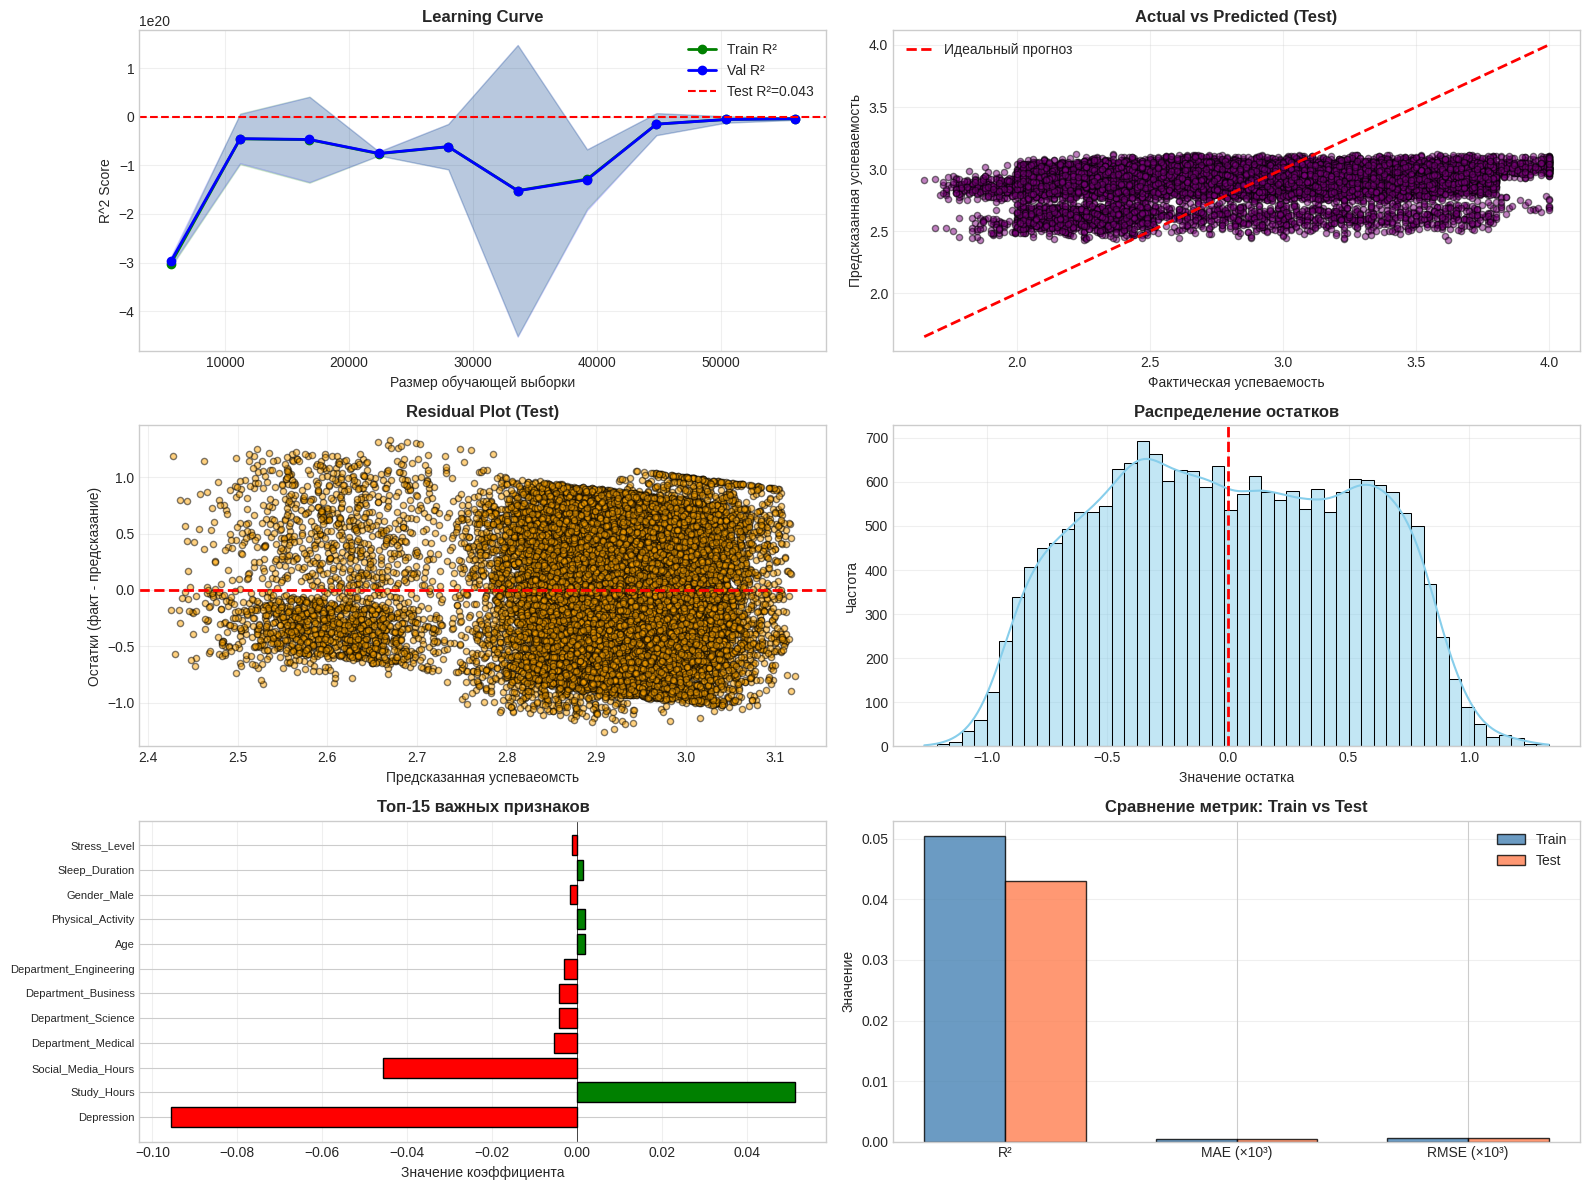

In [23]:
def evaluate_model(y_true, y_pred, dataset_name="Dataset"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    print(f"\n  Выборка: {dataset_name}")
    print(f"  MAE:  {mae:,.2f}")
    print(f"  RMSE: {rmse:,.2f}")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")

    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

train_metrics = evaluate_model(y_train, y_train_pred, "Train")
test_metrics = evaluate_model(y_test, y_test_pred, "Test")
from sklearn.model_selection import learning_curve

plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(16, 12))

ax1 = plt.subplot(3, 2, 1)
train_sizes, train_scores, val_scores = learning_curve(
    model, X_train, y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='r2',
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

ax1.plot(train_sizes, train_mean, 'o-', color='green', label='Train R²', linewidth=2)
ax1.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='green')
ax1.plot(train_sizes, val_mean, 'o-', color='blue', label='Val R²', linewidth=2)
ax1.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='blue')
ax1.set_xlabel('Размер обучающей выборки', fontsize=10)
ax1.set_ylabel('R^2 Score', fontsize=10)
ax1.set_title('Learning Curve', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=test_metrics['R2'], color='red', linestyle='--', lw=1.5, label=f'Test R²={test_metrics["R2"]:.3f}')
ax1.legend()

ax2 = plt.subplot(3, 2, 2)
ax2.scatter(y_test, y_test_pred, alpha=0.5, edgecolors='black', s=20, color='purple')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальный прогноз')
ax2.set_xlabel('Фактическая успеваемость', fontsize=10)
ax2.set_ylabel('Предсказанная успеваемость', fontsize=10)
ax2.set_title('Actual vs Predicted (Test)', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)


ax3 = plt.subplot(3, 2, 3)
residuals = y_test - y_test_pred
ax3.scatter(y_test_pred, residuals, alpha=0.5, edgecolors='black', s=20, color='orange')
ax3.axhline(y=0, color='red', linestyle='--', lw=2)
ax3.set_xlabel('Предсказанная успеваеомсть', fontsize=10)
ax3.set_ylabel('Остатки (факт - предсказание)', fontsize=10)
ax3.set_title('Residual Plot (Test)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)



ax4 = plt.subplot(3, 2, 4)
sns.histplot(residuals, bins=50, kde=True, ax=ax4, color='skyblue', edgecolor='black')
ax4.axvline(x=0, color='red', linestyle='--', lw=2)
ax4.set_xlabel('Значение остатка', fontsize=10)
ax4.set_ylabel('Частота', fontsize=10)
ax4.set_title('Распределение остатков', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)



ax5 = plt.subplot(3, 2, 5)
coefficients = pd.DataFrame({
    'feature': X.columns,
    'coef': model.coef_
})
coefficients = coefficients.sort_values(by='coef', key=lambda x: np.abs(x), ascending=False).head(15)

colors = ['green' if c > 0 else 'red' for c in coefficients['coef']]
bars = ax5.barh(coefficients['feature'], coefficients['coef'], color=colors, edgecolor='black')
ax5.set_xlabel('Значение коэффициента', fontsize=10)
ax5.set_title('Топ-10 важных признаков', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='x')
ax5.axvline(x=0, color='black', lw=0.5)
plt.setp(ax5.get_yticklabels(), fontsize=8)

ax6 = plt.subplot(3, 2, 6)
metrics_names = ['R^2', 'MAE', 'RMSE']
x_pos = np.arange(len(metrics_names))
width = 0.35

train_vals = [train_metrics['R2'], train_metrics['MAE']/1000, train_metrics['RMSE']/1000]
test_vals = [test_metrics['R2'], test_metrics['MAE']/1000, test_metrics['RMSE']/1000]

ax6.bar(x_pos - width/2, train_vals, width, label='Train', alpha=0.8, edgecolor='black', color='steelblue')
ax6.bar(x_pos + width/2, test_vals, width, label='Test', alpha=0.8, edgecolor='black', color='coral')
ax6.set_xticks(x_pos)
ax6.set_xticklabels(['R^2', 'MAE (×10^3)', 'RMSE (×10^3)'])
ax6.set_ylabel('Значение', fontsize=10)
ax6.set_title('Сравнение метрик: Train vs Test', fontsize=12, fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('linear_regression_results.png', dpi=300, bbox_inches='tight')
plt.show()

# Часть 4: Логистическая регрессия
### Предсказываем наличие депрессии у студента
### Категориальные признаки и возраст на этот раз не отбрасываем

### Посмотрим на распределение значений целевой переменной

In [29]:
df['Depression'].value_counts()

,count
Depression,
False,89938
True,10062


#### Видим явный дисбаланс классов
#### Если будем обчать как есть, получим, что модель просто будет всегда предсказывать, что депрессии нет, так как её нет у 90% студентов в датасете
#### С помощью SMOTE искуственно дополним значения минорного класса, чтобы их уравнять, и обучение пройдёт корректно

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve, balanced_accuracy_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

class LogisticRegressionCustom:
    def __init__(self, learning_rate=0.01, n_iterations=100, random_state=42, penalty='l2', alpha=0.01):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.random_state = random_state
        self.penalty = penalty
        self.alpha = alpha
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _initialize_parameters(self, n_features):
        np.random.seed(self.random_state)
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0.0

    def _sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def _compute_loss(self, y_true, y_pred_proba):
        epsilon = 1e-15
        y_pred_proba = np.clip(y_pred_proba, epsilon, 1 - epsilon)
        loss = -np.mean(y_true * np.log(y_pred_proba) + (1 - y_true) * np.log(1 - y_pred_proba))
        if self.penalty == 'l2':
            loss += (self.alpha / (2 * len(y_true))) * np.sum(self.weights ** 2)
        return loss

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self._initialize_parameters(n_features)
        self.loss_history = []

        for epoch in range(self.n_iterations):
            linear_output = np.dot(X, self.weights) + self.bias
            y_pred_proba = self._sigmoid(linear_output)

            loss = self._compute_loss(y, y_pred_proba)
            self.loss_history.append(loss)

            error = y_pred_proba - y
            dw = (1 / n_samples) * np.dot(X.T, error)
            db = (1 / n_samples) * np.sum(error)

            if self.penalty == 'l2':
                dw += (self.alpha / n_samples) * self.weights

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

        return self

    def predict_proba(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear_output)

    def predict(self, X, threshold=0.5):
        proba = self.predict_proba(X)
        return (proba >= threshold).astype(int)


y = df['Depression']
X = df.drop(columns=['Depression'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

model = LogisticRegressionCustom(learning_rate=0.01, n_iterations=200, random_state=42, penalty='l2', alpha=0.01)
model.fit(X_train_balanced, y_train_balanced)

y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)
y_test_proba = model.predict_proba(X_test_scaled)


TRAIN:
  Accuracy: 0.5652
  Balanced Accuracy: 0.6363
  Precision: 0.1520
  Recall: 0.7253
  F1: 0.2513

TEST:
  Accuracy: 0.5587
  Balanced Accuracy: 0.6216
  Precision: 0.1463
  Recall: 0.7003
  F1: 0.2420
  AUC-ROC: 0.6731


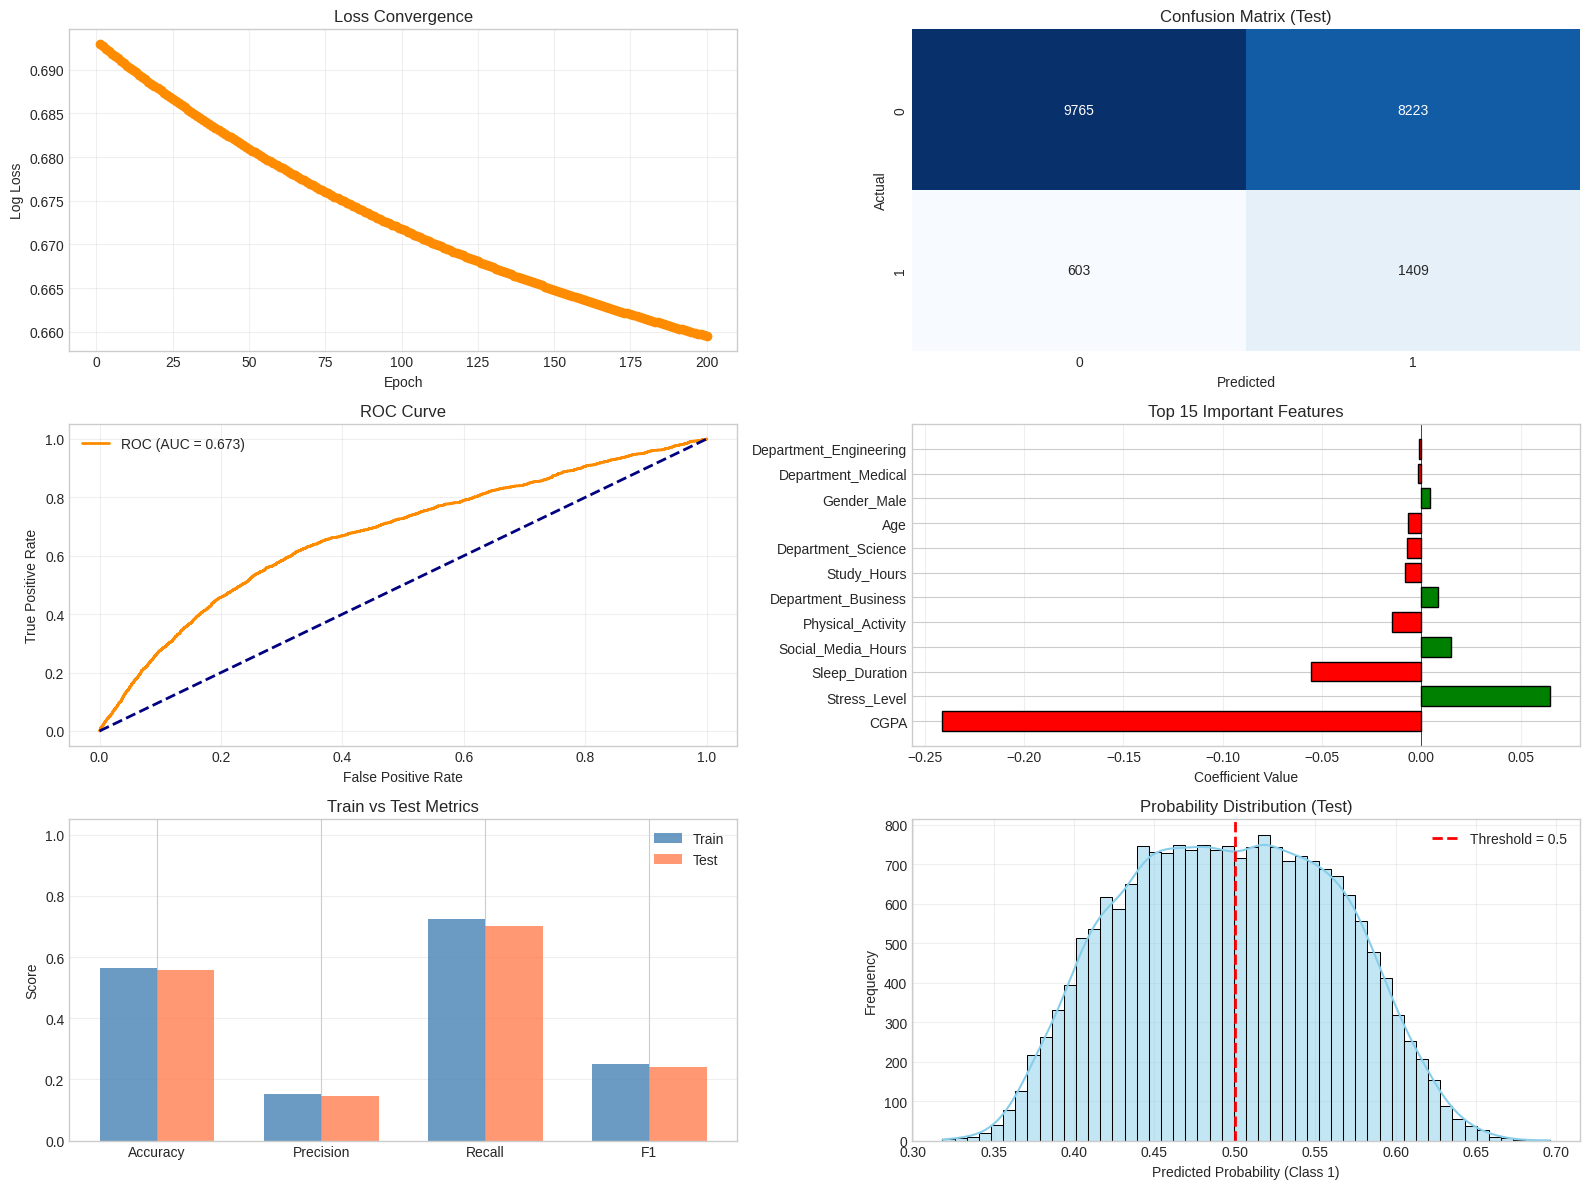


Optimal threshold search:
  Threshold 0.3: F1=0.183
  Threshold 0.4: F1=0.188
  Threshold 0.5: F1=0.242
  Threshold 0.6: F1=0.174
  Threshold 0.7: F1=0.000

Best threshold: 0.5 (F1=0.242)


In [25]:
def evaluate(y_true, y_pred, y_proba=None, name="Dataset"):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba) if y_proba is not None else None

    print(f"\n{name}:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  Balanced Accuracy: {bal_acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall: {rec:.4f}")
    print(f"  F1: {f1:.4f}")
    if auc:
        print(f"  AUC-ROC: {auc:.4f}")

    return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'AUC-ROC': auc}

train_metrics = evaluate(y_train, y_train_pred, name="TRAIN")
test_metrics = evaluate(y_test, y_test_pred, y_test_proba, name="TEST")

plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(16, 12))

ax1 = plt.subplot(3, 2, 1)
ax1.plot(range(1, len(model.loss_history) + 1), model.loss_history, 'o-', color='darkorange', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Log Loss')
ax1.set_title('Loss Convergence')
ax1.grid(True, alpha=0.3)

ax2 = plt.subplot(3, 2, 2)
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2, cbar=False)
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')
ax2.set_title('Confusion Matrix (Test)')

ax3 = plt.subplot(3, 2, 3)
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
ax3.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {test_metrics["AUC-ROC"]:.3f})')
ax3.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title('ROC Curve')
ax3.legend()
ax3.grid(True, alpha=0.3)

ax4 = plt.subplot(3, 2, 4)
weights_df = pd.DataFrame({'feature': X.columns, 'weight': model.weights})
weights_df = weights_df.sort_values(by='weight', key=lambda x: np.abs(x), ascending=False).head(15)
colors = ['green' if w > 0 else 'red' for w in weights_df['weight']]
ax4.barh(weights_df['feature'], weights_df['weight'], color=colors, edgecolor='black')
ax4.set_xlabel('Coefficient Value')
ax4.set_title('Top 15 Important Features')
ax4.axvline(x=0, color='black', lw=0.5)
ax4.grid(True, alpha=0.3, axis='x')

ax5 = plt.subplot(3, 2, 5)
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1']
x_pos = np.arange(len(metrics_names))
width = 0.35
train_vals = [train_metrics['Accuracy'], train_metrics['Precision'], train_metrics['Recall'], train_metrics['F1']]
test_vals = [test_metrics['Accuracy'], test_metrics['Precision'], test_metrics['Recall'], test_metrics['F1']]
ax5.bar(x_pos - width/2, train_vals, width, label='Train', alpha=0.8, color='steelblue')
ax5.bar(x_pos + width/2, test_vals, width, label='Test', alpha=0.8, color='coral')
ax5.set_xticks(x_pos)
ax5.set_xticklabels(metrics_names)
ax5.set_ylabel('Score')
ax5.set_title('Train vs Test Metrics')
ax5.set_ylim(0, 1.05)
ax5.legend()
ax5.grid(True, alpha=0.3, axis='y')

ax6 = plt.subplot(3, 2, 6)
sns.histplot(y_test_proba, bins=50, kde=True, ax=ax6, color='skyblue', edgecolor='black')
ax6.axvline(x=0.5, color='red', linestyle='--', lw=2, label='Threshold = 0.5')
ax6.set_xlabel('Predicted Probability (Class 1)')
ax6.set_ylabel('Frequency')
ax6.set_title('Probability Distribution (Test)')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('logistic_regression_results.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nOptimal threshold search:")
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
best_f1 = 0
best_th = 0.5
for th in thresholds:
    y_pred_custom = (y_test_proba >= th).astype(int)
    f1_curr = f1_score(y_test, y_pred_custom)
    print(f"  Threshold {th}: F1={f1_curr:.3f}")
    if f1_curr > best_f1:
        best_f1 = f1_curr
        best_th = th

print(f"\nBest threshold: {best_th} (F1={best_f1:.3f})")

### Наблюдаем практически отсутствие разницы метрик на train-е и на test-е
### test metrics < train metrics на 0.01-0.02, что показывает отсутствие переобучения

# Часть 5: Анализ и выводы

## Линейная регрессия:
#### * Анализ графиков не показал явной корелляции ни с одним из признаков
#### * Низкий показатель R^2 говорит о том, что модель толком не нашла никаких закономерностей
#### * Метрики MAE и RMSE показывают хорошие значения в виду того, что модель попросту стала предсказывать среднее значение CGPA независимо от истинного значения
#### * Это равноценно тому, если бы мы просто посчитали среднее значение и писали бы его "вслепую" на любые данные, это наглядно демонстрирует график ACTUAL vs PREDICTED
#### * Так что в привидённом датасете предсказывать средний балл успеваемости студента через линейную регрессию не будет эффективно

## Логистическая регрессия:
#### * Анализ графиков выявил  положительную корреляцию целевой переменной с уровнем стресса
#### * С наличием депрессии отрицательно коррелирует CGPA: чем выше средний балл успеваемости, чем ниже вероятность депрессии
#### * Также отрицательная корреляция с количествов сна: чем больше часов сна, тем ниже вероятность депрессии
#### ROC-AUC показывает нормальное значение, это явно лучше случайного прогноза
#### Подбор порогового значения остановился на значении 0.5, так как принём было максимальное значение F1